# Condensator Ontwerpopdracht

Bij het vak elektromagnetisme zullen jullie in de eerste paar weken diep ingaan op de elektrostatica. Parallel hieraan zullen we bij het vak DEF-D, naast de fysieke ontwerpopdrachten en colleges, deze simulatie-ontwerpopdracht behandelen. Deze simulatie-opdracht is weer nauw verwoven met de tweede fysieke ontwerpopdracht die in week 3.3 gegeven wordt. Je moet het grootste deel van deze simulatie opdracht afronden voordat je aan de fysieke ontwerpopdracht van week 3.3 begint. Het laatste stuk van deze simulatie opdracht maak je na afloop van de fysieke opdracht. De deadline voor het inleveren van deze simulatie-opdracht is in week 3.4

Je werkt bij deze opdracht in teams die wij indelen. Zoek op Brightspace op met wie je samenwerkt en leg via email contact. Maak goede afspraken over hoe je samen gaat werken.

In deze simulatie opdracht beginnen we met een aantal simulaties van verschillende situaties, die jullie daarna zullen interpreteren. Daarna zal wat essentiële voorbereiding op de tweede fysieke ontwerpopdracht besproken worden. En als laatste zal dieper ingegaan worden op hoe jullie metingen van de tweede ontwerpopdracht afwijken van de theorie.

De opdracht bestaat uit de volgende sub-opdrachten die je moet doen voordat je begint aan de fysieke ontwerpopdracht van week 3.3:
1) Een puntlading in de oorsprong.
2) Een uniform geladen schijf bestaande uit puntladingen.
3) Een geladen schijf op een constant potentiaal.
4) Twee geleidende platen op potentiaal $V_1$ and $-V_1$.
5) Voorbereidende opdracht voor de DEF ontwerpopdracht.

Na de fysieke ontwerpopdracht van week 3.3 kan je ten slotte het laatste deel doen:

6) Reflectie opdracht voor na de fysieke ontwerpopdracht.

De opdracht wordt volledig online gedaan, er zullen hiervoor dus ook geen specifieke werkcolleges voor zijn ingeroosterd. Als jullie vragen hebben kunnen jullie die mailen naar het DEF e-mailadres: DEF-TNW@tudelft.nl. Deze opdracht wordt in week 3.4 beoordeeld en herkansingen zijn in week 3.5, zie de studiehandleiding voor details.
   
Technische Instructies:
- Git clone (als nog niet gedaan) het DEF repo en maak een branch voor werken aan deze opdracht. Nodig je groepsgenoot uit als collaborator. Hiervoor staat een manual op brightspace.
- Dit notebook maakt gebruik van een aantal functies die in het bestand ```functions_electrostatics.py``` staan. Dit bestand moet in dezelfde map (folder) staan als dit notebook. Als je git clone doet, gaat dat automatisch goed, maar verplaats dit notebook dus niet naar een andere map, mail het niet naar een mede-student, etc. Als je niet weet wat een map (folder) en een bestand is, bekijk dan [deze tutorial](https://teachbooks.io/files-and-folders/EN/intro.html).

Onderwijs Instructies:
- Beantwoord de vragen die in dit notebook voor komen direct in dit notebook.
- Als je iets moet printen op het scherm als antwoord op een vraag, doe dit op een gestructureerde manier met als dat relevant is de eenheid erbij, zoals je geleerd is bij het Inleidend Practicum.
- Vermijd 'hardcoden' waar mogelijk.
- Bij elke code cel staat aangegeven of jij hem moet aanpassen of alleen runnen. Lees bij cellen die je moet runnen, maar niet hoeft aan te passen, goed de code door om daarvan te leren en te gebruiken in de cellen die je wel moet aanpassen.

Elektrostatica Opmerkingen:
- In deze opdracht zullen jullie verschillende problemen bestuderen die as-symmetrie hebben. De opdrachten zullen daardoor, cilindrische coördinaten ($r$,$\phi$,$z$) gebruiken, waarbij $r$ de afstand tot de $z$ as is, $z$ de hoogte en $\phi$ de hoek met de $x$-as. Alle gebruikte problemen zullen ook in de $\phi$ richting symmetrisch zijn en die coördinaat zal dus niet uitmaken.
- Voor elke sub-opdracht zal eerst het potentiaal bepaald worden en daarna zal het elektrische veld bepaald worden met de "finite difference" methode. Dit is een methode om de afgeleide te nemen van een dataset. Deze methode is geen onderdeel van de leerdoelen van het vak en komt later in je studie aan bod. We gebruiken "finite difference" hier als gereedschap en als voorbeeld van wat je later nog tegen gaat komen.



Vul de informatie in deze cel in:

| Groep: 81     |  |
| :-------------|:-------------|
| Thomas de Ruyter van Steveninck| 6528244|
| Erik van den Berg| 6328407 |

In [1]:
# Run deze cel, pas deze niet aan
import numpy as np
import matplotlib.pyplot as plt
from functions_electrostatics import *
#from IPython import display
from IPython.display import Image, display


epsilon0 = 8.854e-12  # permittiviteit van vacuum (F/m)

"""============================================================================================
We first define the size of the domain of calculation and spatial discretization of the domain
"""

# Grid van het rekendomein; het veld wordt berekend in het (r,z)-vlak (asymmetrie):
width_domain = 5  # (m)
height_domain = width_domain  # maximum afstand van de schijf tot de grond, boven en beneden (m)
grid_step = 0.1  # grid stap grootte (m)

### 1) Een puntlading in de oorsprong

In deze opdracht gaan we in op een numerieke benadering van het potentiaal en elektrische veld rond een puntlading in de oorsprong. 

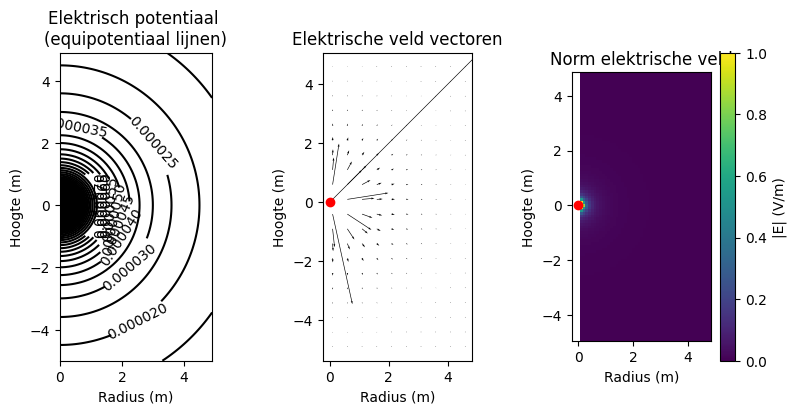

In [2]:
# Run deze cel, pas de cel niet aan
charge_one_point = 1e-14  # lading van 1 punt (C)

r, z, B = initialize_plane_grid_for_pt_charge_at_origin(height_domain, width_domain, grid_step)
V = calculate_V_point_charge_at_origin(charge_one_point, r, z)

Er, Ez, normE = compute_E_pt_charge(V, B, grid_step)  # gebruik de centered finite-difference method
# met Er de r-component, Ez de z-component en normE de norm van het elektrische veld

r_for_E = r[1:-1]  # de centered finite-difference method kan E niet berekenen op het allereerste en allerlaatste gridpunt in de r-dimensie
z_for_E = z[1:-1]  # de centered finite-difference method kan E niet berekenen op het allereerste en allerlaatste gridpunt in de z-dimensie

plot_results_pt_charge_at_origin(Ez, Er, normE, V, r, z, grid_step)


##### Vraag 1a Het potentiaal rond een puntlading

1. Bepaal welke index correspondeert met $z = 0$ m.
2. Plot de log van het potentiaal tegen de log van de straal.
3. Fit de log van het potentiaal met de log van de straal.
4. Print het exponent op een nette manier.

(100, 50)
De index die correspondeert met z=0 is 50.


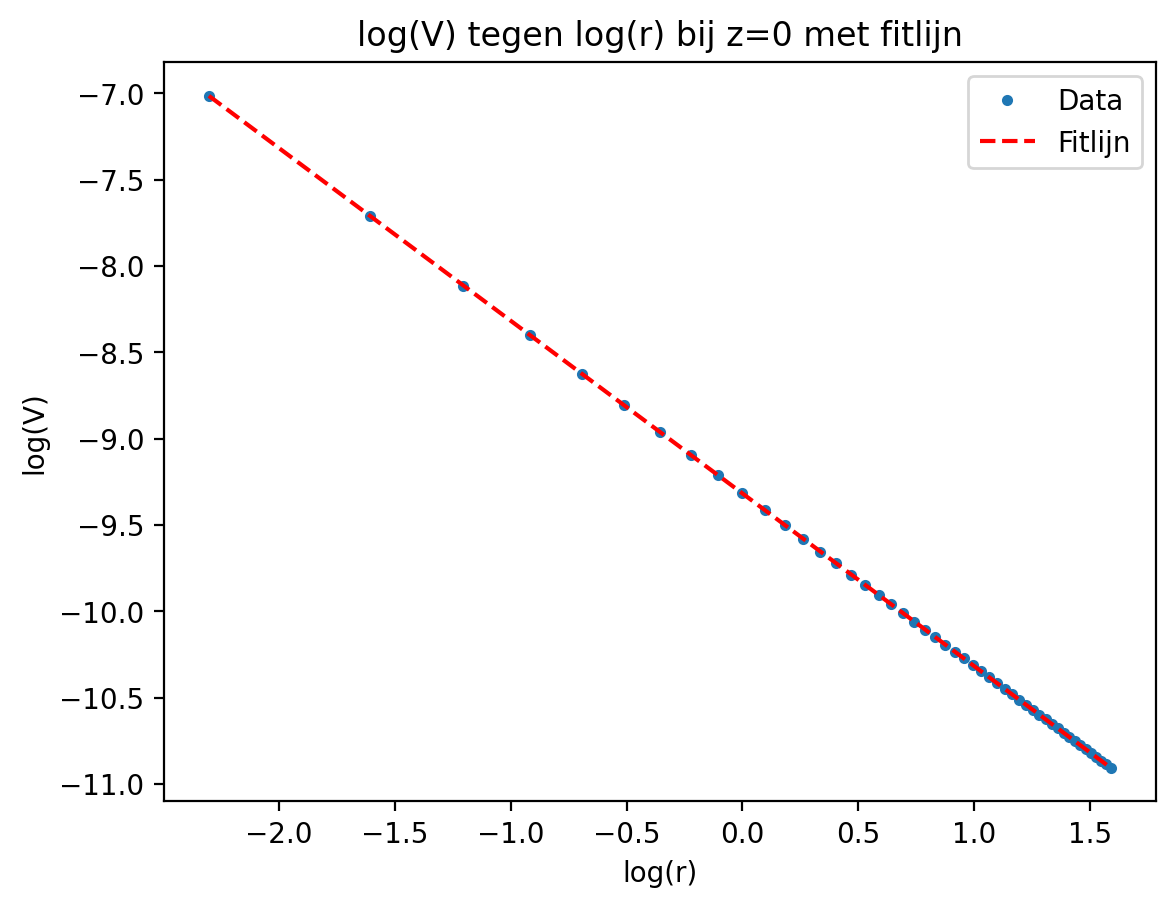

De waarde van de exponent a is -1.000e+00 met een onzekerheid van 1.349e-16


In [3]:
#1. index bij z=0 bepalen
print(V.shape) # dit is (100,50). Die 100 gaat over de z-waarde en de 50 over de r-waarde.
z_index_bij0 = np.argmin(np.abs(z))
print('De index die correspondeert met z=0 is {}.'.format(z_index_bij0))

#2. plotten van de log log
V_z0 = V[z_index_bij0, :] # Hier neem ik alle potentiaal waarden bij z=0.

filter = r > 0 # je kan niet een log van nul of een negatief getal nemen dus die moet je eruit filteren. 
r_zondernul= r[filter]
V_zondernul = V_z0[filter]

logr = np.log(r_zondernul)
logV = np.log(V_zondernul)

#3. fit maken
from scipy.optimize import curve_fit

def fitfunctie(logr, a, b):
    return a * logr + b

val, cov = curve_fit(fitfunctie, logr, logV)
a_fit = val[0]
b_fit = val[1]
a_err = np.sqrt(cov[0,0])
b_err = np.sqrt(cov[0,0])

logr_fit = np.linspace(min(logr), max(logr), 1000)
logV_fit = fitfunctie(logr_fit, a_fit, b_fit)

plt.figure(dpi=200)
plt.plot(logr, logV, '.', label='Data')
plt.plot(logr_fit,logV_fit,'r--',label='Fitlijn')
plt.xlabel('log(r)')
plt.ylabel('log(V)')
plt.legend()
plt.title('log(V) tegen log(r) bij z=0 met fitlijn')
plt.show()

#4. printen van de waarde
print('De waarde van de exponent a is {:.3e}'.format(a_fit),'met een onzekerheid van {:.3e}'.format(a_err))



Vraag 1b Het elektrische veld rond een puntlading

1. Voer van vraag 1a 2 tot 4 uit voor het elektrische veld.

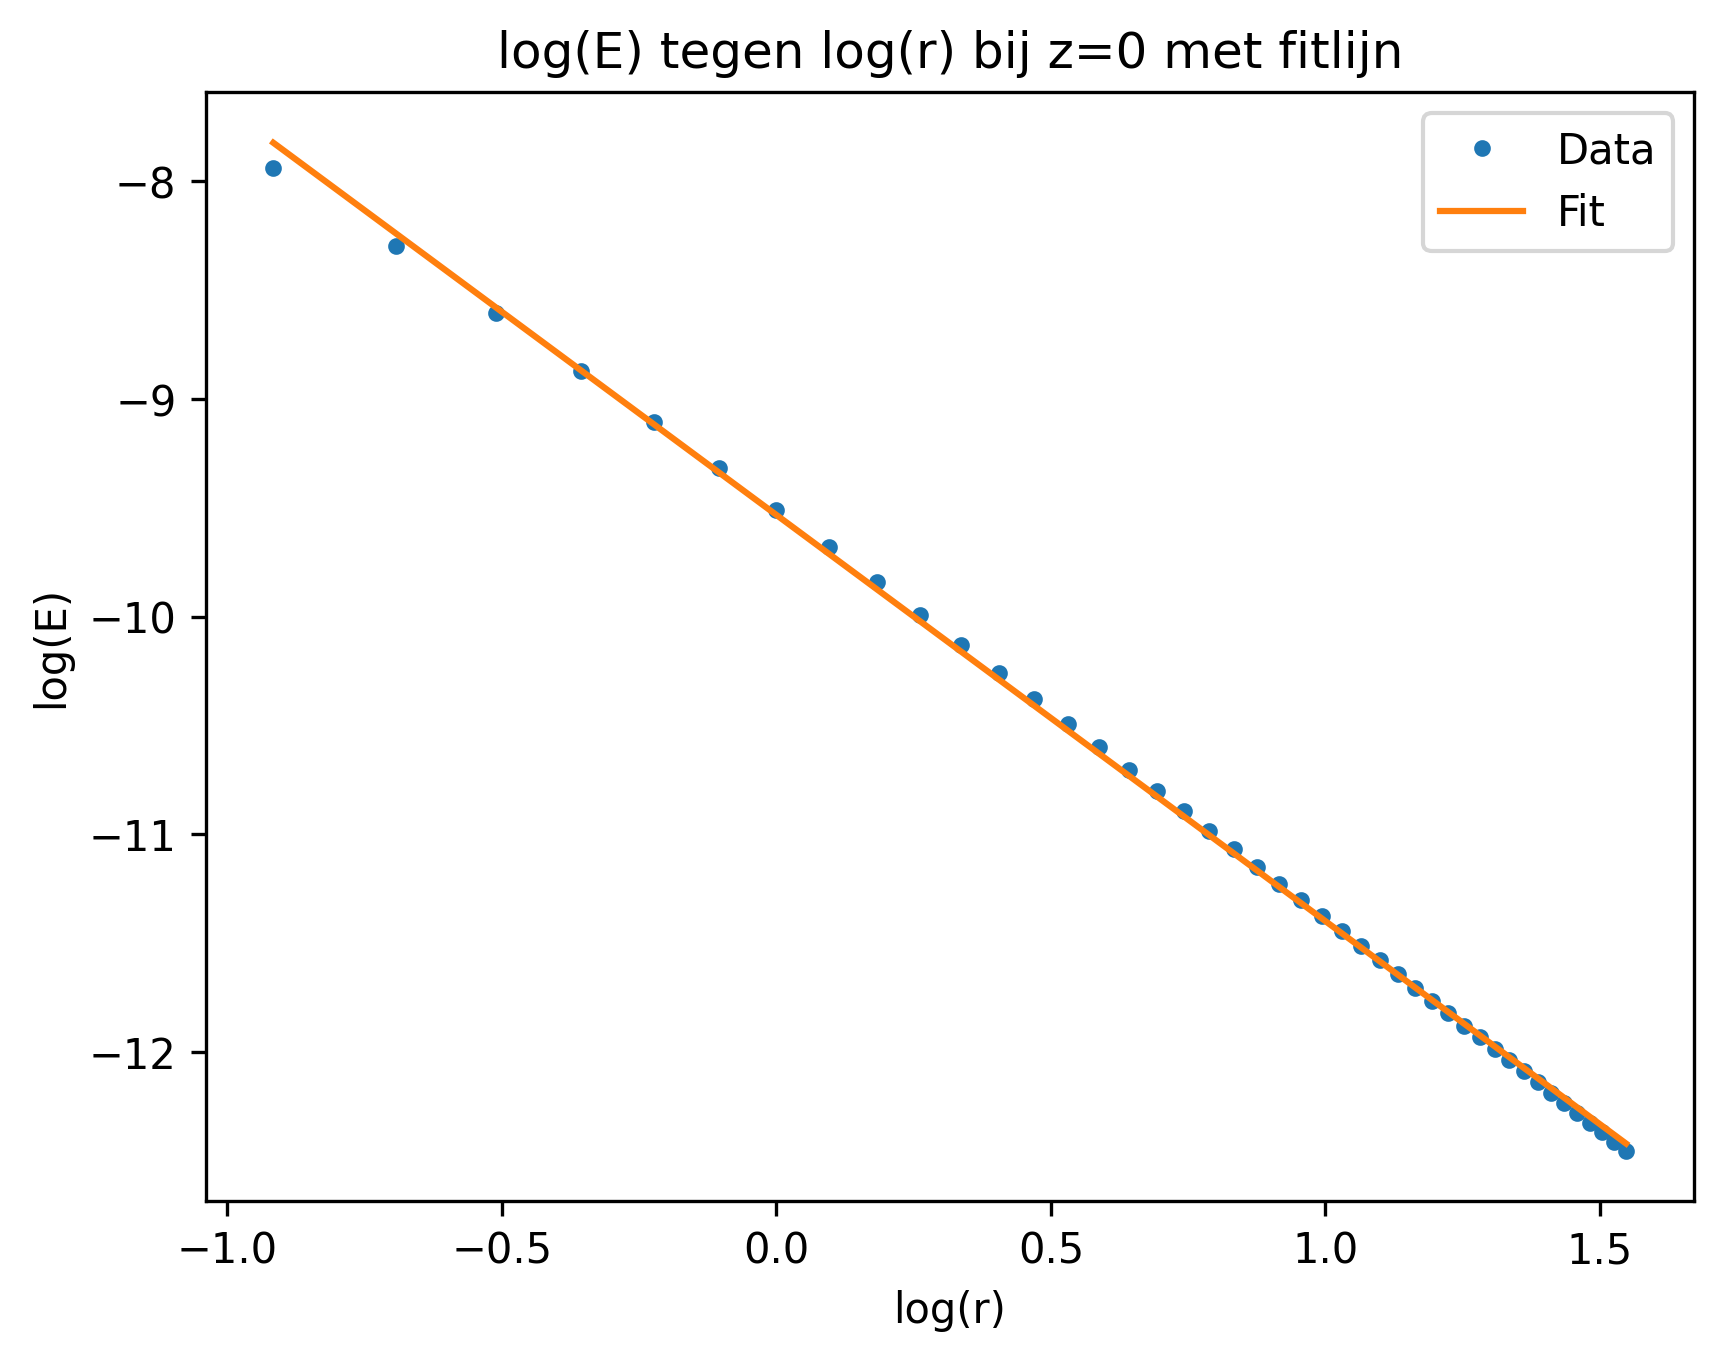

De waarde van de exponent a is -1.867e+00 met een onzekerheid van 6.899e-03.


In [4]:
E_z0 = normE[z_index_bij0, :] # veld bij z=0 nemen
r_E = r[:len(E_z0)] #zodat r_E dezelfde legte heeft als E_z0

filter = r_E > 0 # nul eruit halen voor de logaritme
r_zondernul = r_E[filter]
E_zondernul = E_z0[filter]

logr = np.log(r_zondernul)
logE = np.log(E_zondernul)

def model(logr, a, b):
    return a * logr + b

val, cov = curve_fit(model, logr[3:], logE[3:]) # ik slice de drie eerste metingen eruit omdat die te veel invloed hebben om de lineare fit, terwijl ze niet op in lijn met de rest van de punten liggen.
a_fit = val[0]
b_fit = val[1]
a_err = np.sqrt(cov[0,0])
b_err = np.sqrt(cov[0,0])

logr_fit = np.linspace(min(logr[3:]), max(logr[3:]), 1000)
logE_fit = model(logr_fit, a_fit, b_fit)

plt.figure(dpi=300)
plt.plot(logr[3:], logE[3:], '.', label='Data')
plt.plot(logr_fit, logE_fit, '-', label='Fit')
plt.xlabel('log(r)')
plt.ylabel('log(E)')
plt.title('log(E) tegen log(r) bij z=0 met fitlijn')
plt.legend()
plt.show()

print('De waarde van de exponent a is {:.3e}'.format(a_fit),'met een onzekerheid van {:.3e}.'.format(a_err))


### 2) Een uniform geladen schijf bestaande uit puntladingen

In de code hieronder wordt een geladen schijf gemaakt via het superpositie principe. Dit wordt gedaan door een rooster van punten in de ruimte te creëren, alle punten die voldoen aan $z = 0$ m en $r < R$ krijgen een lading charge_one_point en vanuit hier wordt het potentiaal bepaald. Hier is de $z$-as de as van de schijf en de r as de afstand tot de $z$-as.



In [5]:
# In vraag 2.1 wordt naar deze cel verwezen.
disk_radius = 3  # 3(m)
grid_step = 0.1  # 0.1(m)
z_coord_DISK = 0  # 0(m) positie van de schijf op de z-as
inter_charge_distance = grid_step  # (m) afstand tussen punt ladingen

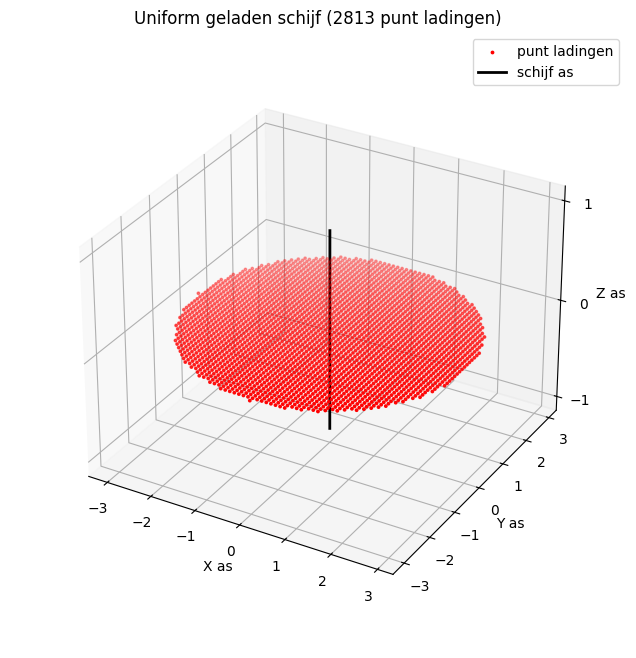

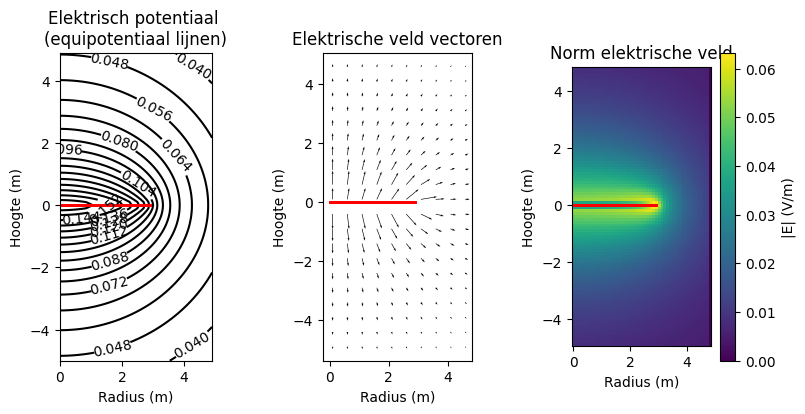

In [6]:
# Kies uit deze cel een van de variabelen en verander die in de cel hierboven pas deze cel zelf niet aan.
r, z, B = initialize_plane_grid_for_uniformly_charged_disk(height_domain, width_domain, grid_step)

idx_z_zero = np.where(abs(z) < 1e-10)[0]
z_coord_DISK = 0  # (m) positie van de schijf op de z-as
inter_charge_distance = grid_step  # (m) afstand tussen punt ladingen

V, number_point_charges_on_disk = calculate_V_disk_at_origin_uniform_surface_charge_density(z_coord_DISK, charge_one_point, disk_radius, inter_charge_distance, r, z)
Er, Ez, normE = compute_E_disk(V, B, grid_step)  # gebruik de centered finite-difference method

r_for_E = r[1:-1]  # de centered finite-difference method kan E niet berekenen op het allereerste en allerlaatste gridpunt in de r-dimensie
z_for_E = z[1:-1]  # de centered finite-difference method kan E niet berekenen op het allereerste en allerlaatste gridpunt in de z-dimensie

plot_results_disk(Ez, Er, normE, V, r, z, grid_step, disk_radius, z_coord_DISK, z_coord_DISK)

#### Vraag 2a

In deze vraag gaan jullie achterhalen wat de variabelen die aan het begin van opgave 2 worden geïnitialiseerd betekenen voor de nauwkeurigheid en snelheid van de code.
Pas voor deze vraag de code die net onder het kopje vraag 2 staat aan. Run dan die cel en de cel daaronder opnieuw om het resultaat van je aanpassing te zien.
1. Wat betekent de disk radius variabele die in de bovenste cel geïnitialiseerd wordt, wat gebeurt er als disk radius naar 0 gaat?
2. Wat betekent gridstep en wat voor impact heeft deze variabele op de simulatie?
3. Pak uit de tweede code cel in opdracht 2 een andere variabelen en onderzoek wat deze variabele doet en wat voor impact die heeft op de simulatie.

##### Antwoorden 2a

1. De disk radius is de straal van de schijf. Als deze naar nul gaat, wordt er geen schijf geplot. Het aantal punten per oppervlakte is constant, dus als de straal verhoogd wordt, groeit het aantal punten kwadratisch. Zo worden er 315 punten geplot bij een straal van 1 en 31411 punten bij een straal van 10.

2. De gridstep past aan wat de afstand is tussen de verschillende deeltjes in de schijf. Deze variabele bepaalt dus ook hoeveel deeltjes er geplot worden in een schijf met dezelfde straal. Als je deze variabele groter kiest, wordt de resolutie van de onderste afbeeldingen ook lager: er verschijnen minder vectoren en de blokjes van de norm worden groter. Verder schaalt ook deze variabele ongeveer kwadratisch.

3. De variabele z_coord_DISK geeft de hoogte van de schijf aan. Als deze veranderd wordt, verschuift de schijf alleen in de onderste figuren, niet in de plot.

#### Vraag 2b Oppervlakte lading

Pas de cel die je in vraag 2a hebt aangepast weer aan naar de originele waardes. Run hierna alle code cellen na vraag 2 weer opnieuw.
Het aantal punten dat gebruikt wordt om de schijf te creëren is number_point_charges_on_disk en de lading van een punt is charge_one_point in Coulomb.
1. Bereken en print de ladingsdichtheid $\sigma$ met een correcte eenheid.

In [7]:
schijfOpp = np.pi*disk_radius**2
schijfLading = charge_one_point*number_point_charges_on_disk
def sigma(Q,A): 
    return Q/A
print("De ladingsdichtheid sigma = {:.2e}".format(sigma(schijfLading,schijfOpp)),"C/m^2")

De ladingsdichtheid sigma = 9.95e-13 C/m^2


##### Vraag 2c

1. Plot het elektrische potentiaal langs de $r$ as ($z = 0$ m).
2. Plot het potentiaal op de rand van de schijf in hetzelfde figuur $V = \sigma R/(\pi \epsilon_0)$
(bekijk probleem 2.51 in het Griffiths' boek)
3. Plot het potentiaal in het centrum van de schijf in hetzelfde figuur $V = \sigma R/(2 \epsilon_0)$

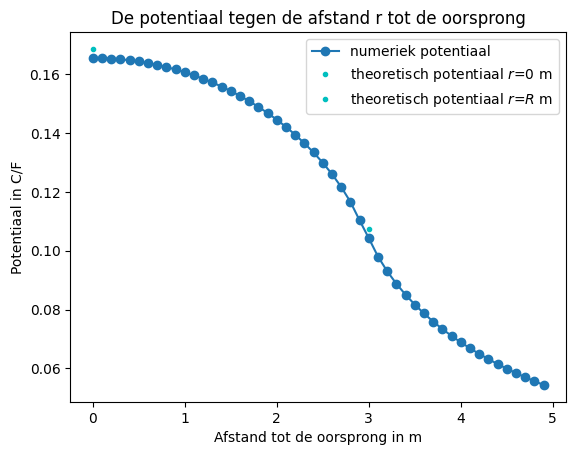

In [8]:
# Vul deze code aan zodat deze vraag 2.3 beantwoord.
idx_z_zero = np.where(abs(z) < 1e-10)[0]

V_0 = (sigma(schijfLading,schijfOpp)*disk_radius)/(2*epsilon0) # potentiaal op r = 0
V_R =  (sigma(schijfLading,schijfOpp)*disk_radius)/(np.pi*epsilon0)# potentiaal op de straal van de schijf
r_R =  disk_radius  # straal van de schijf

plt.title(f"De potentiaal tegen de afstand r tot de oorsprong")
plt.plot(r, V[50], "o-", label="numeriek potentiaal")
plt.plot(0, V_0, "c.", label="theoretisch potentiaal $r$=0 m")
plt.plot(r_R, V_R, "c.", label="theoretisch potentiaal $r$=$R$ m")
plt.legend()
plt.xlabel("Afstand tot de oorsprong in m")
plt.ylabel("Potentiaal in C/F")
plt.show()


#### Vraag 2d

Het theoretische potentiaal op de as van een hele grote schijf ($R>>z$) is:
$V(z, r=0) = \frac{\sigma}{2\epsilon_0} \big( R - |z|\big)$
zie probleem 2.26 in het Griffiths boek.
1. Plot het numeriek berekend elektrische potentiaal op de $z$-as ($r=0$).
2. Plot het theoretische component van het potentiaal op de as van een schijf met ladingsdichtheid $\sigma$.
3. Sla deze plot op.


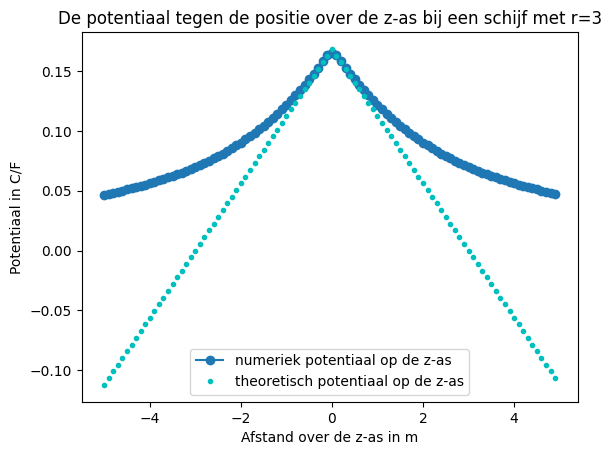

De theoretische potentiaal gaat onder de nul, omdat voor hogere waardes de voorwaarde R >> z niet meer voldaan is. 
R is namelijk 3 en z loopt van -5 tot 5.


In [9]:
V_r0 = sigma(schijfLading,schijfOpp)*(disk_radius-np.abs(z))/(2*epsilon0)

plt.figure()
plt.title(f"De potentiaal tegen de positie over de z-as bij een schijf met r=3")
plt.plot(z, V[:,0], "o-", label="numeriek potentiaal op de z-as")
plt.plot(z, V_r0, "c.", label="theoretisch potentiaal op de z-as")
plt.legend()
plt.xlabel("Afstand over de z-as in m")
plt.ylabel("Potentiaal in C/F")
plt.savefig("Opdracht2d_potentiaal_r=3.png")
plt.show()

print("De theoretische potentiaal gaat onder de nul, omdat voor hogere waardes de voorwaarde R >> z niet meer voldaan is. \nR is namelijk 3 en z loopt van -5 tot 5.")

#### Vraag 2e

Het theoretische elektrische veld van een oneindig, geladen oppervlakte is $|E| = \sigma/(2 \epsilon_0)$ (zie Example 2.5 in het Griffith boek).
1. Plot het z-component van het numeriek berekende elektrische veld op de as van de schijf ($r=0$).
2. Plot het theoretische elektrische veld voor een oneindig, geladen oppervlak.
3. Sla deze plot ook op.

(array([51]),)
0.09999999999998188
(array([47]),)
-0.3000000000000167


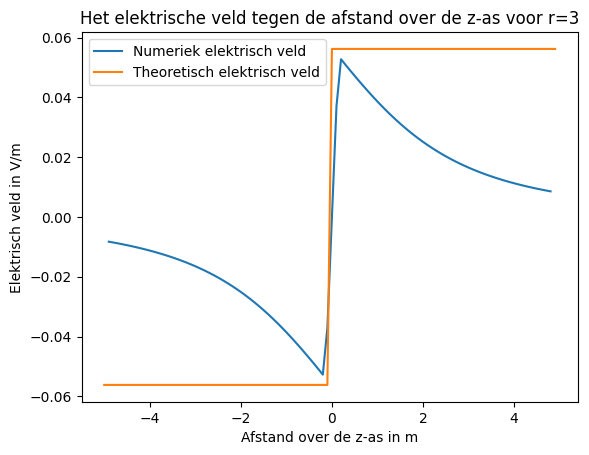

In [10]:
E_theorie = np.abs(sigma(schijfLading,schijfOpp)/(2*epsilon0))
E_theorie = np.concatenate([[-E_theorie] * 50,[E_theorie]*50])

plt.title("Het elektrische veld tegen de afstand over de z-as voor r=3")
plt.plot(z_for_E, Ez[:,0], label = "Numeriek elektrisch veld")
plt.plot(z, E_theorie, label = "Theoretisch elektrisch veld")
plt.ylabel("Elektrisch veld in V/m")
plt.xlabel("Afstand over de z-as in m")
plt.legend(loc = 'best')
plt.savefig("Opdracht2e_elektrisch_veld_r=3")

print(np.where(Ez[:,0] == np.max(Ez[:,0]))) #De maximale waarde van het elektrische veld vinden
print(z[51]) #Hier is het elektrisch veld maximaal
print(np.where(Ez[:,0] == np.min(Ez[:,0]))) #De minimale waarde van het elektrische veld
print(z[47]) # Hier is het veld minimaal

#### Vraag 2f
1. Waar benadert het elektrische veld van een uniform geladen schijf dat van een oneindig geladen plaat?
2. Beschrijf en verklaar de verschillen die je opvallen in de plot die je bij vraag 2e hebt gemaakt.

##### Antwoorden 2f

1. De maximale waarde van het numeriek berekende elektrische veld, dus waar het numerieke veld het elektrische veld van een oneindige, geladen schijf het best benaderd, is op z = 0.1 en bij z = -0.3.
2. Het numeriek berekende elektrische veld gaat onder nul bij negatieve z-waardes en is nul bij z = 0. Het elektrische veld van de oneindige, geladen schijf is totaal onafhankelijk van de z-waarde, maar klapt wel om van richting bij z = 0. De z-onafhankelijkheid is logisch, omdat je steeds meer lading 'te zien' krijgt als je je verder verwijdert van de schijf. Dit compenseert voor het verkleinende effect dat ieder deeltje op het veld heeft. Je kan zogenaamd niet ontsnappen van een oneindige schijf.

#### Vraag 2g

1. Pas helemaal bovenaan in vraag 2 de straal van de schijf aan.
2. Voer dan vragen 2d en 2e opnieuw uit.
3. Voeg de opgeslagen figuren hieronder toe.
4. Beschrijf de verschillen tussen de twee verschillende stralen.

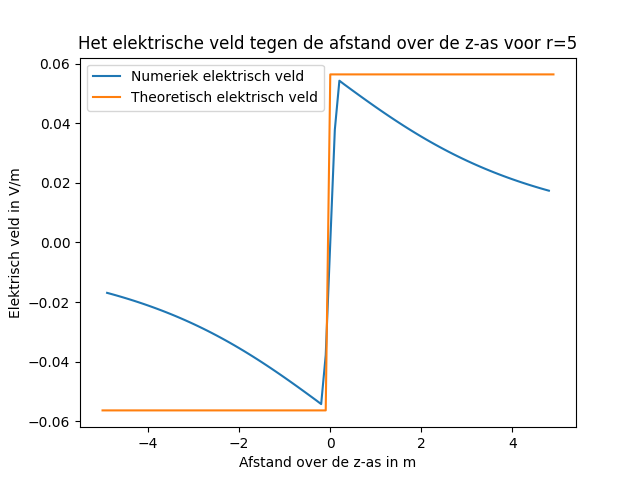

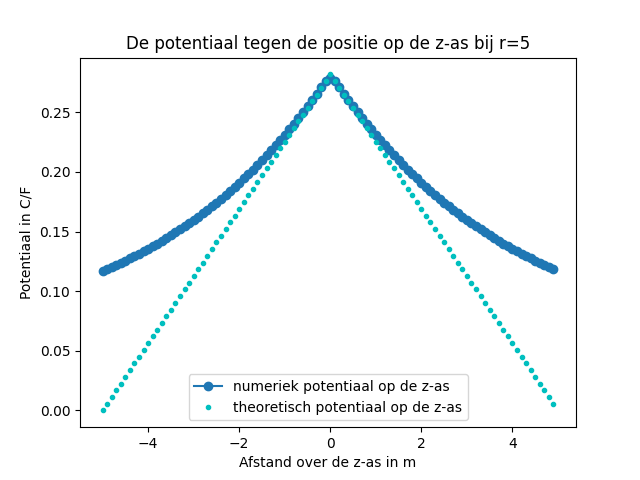

In [11]:

display(Image("Opdracht2e_elektrisch_veld_r=5.png"))
display(Image("Opdracht2d_potentiaal_r=5.png"))

##### Antwoorden 2g
4. Het elektrische veld neemt bij r=3 sneller af, bij grotere afstanden over de z-as. Ook de potentialen, de numerieke en de theoretische, nemen bij r=3 sneller af. Dit is logisch, omdat er bij r=5 meer geladen deeltjes zijn, die het veld op grotere z-waardes dus beter kunnen handhaven. Bij r=5 komt de theoretische potentiaal voor meer z-waardes overeen met de numerieke potentiaal. Dit wordt veklaard doordat de voorwaarde R>>z voor meer z-waardes voldaan wordt.


#### Vraag 2h
Het elektrische veld een afstand $z$ boven het midden van een uniform geladen schijf met een straal $R$ en oppervlakte lading $\sigma$ wordt gegeven door:
$$ \mathbf{E} = \frac{\sigma}{2\epsilon_0} \bigg[ 1- \frac{z}{\sqrt{R^2 + z^2}}\bigg] \hat{\mathbf{z}}$$
Zie probleem 2.6 in het boek van Griffith.

1. Wat moet de hoogte $z$ zijn boven de schijf zodat het elektrische veld door de schijf 10% is in vergelijking met dat van een oneindig geladen plaat?

Voeg hieronder je analytische uitwerking toe.

##### Antwoord 2h

1. Het elektrisch veld voor een oneindige, geladen plaat wordt voor positieve z gegeven door E=sigma/(2*epsilon0). Om 10% hiervan te bereiken, moet de term: 1-z/sqrt(R^2+z^2) gelijk zijn aan 0.1. Dit levert z^2 = 0.81(z^2+R^2) oftewel 0.19z^2 = 0.81R^2.
Hieruit volgt dat z = sqrt(4.26)*R. 

### 3) Een geladen schijf op een constant potentiaal

We zullen nu het verschil bestuderen tussen een uniform geladen schijf en een geleidende schijf die op een bepaald potentiaal gehouden wordt.
De code hieronder lost numeriek de laplace vergelijking op voor een geleidende schijf op een constant potentiaal. Hieruit volgt het potentiaal in de ruimte.

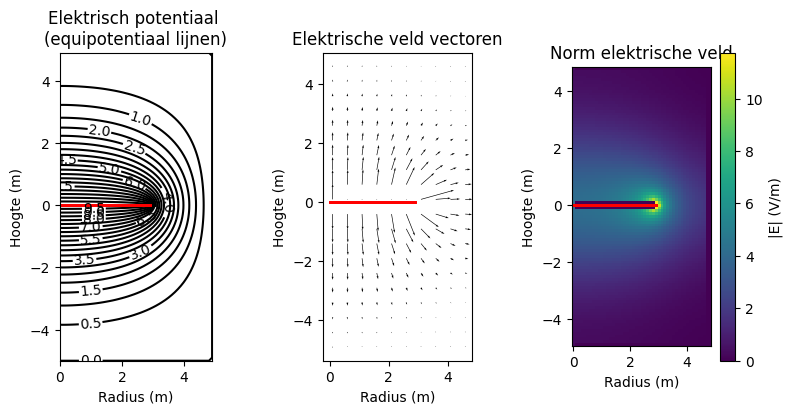

In [12]:
# Run deze cel pas deze niet aan.
V0 = 0  # electric potential at boundary of domain (V)

# Één schijf
z_pos_disk1 = 0  # z-coördinaat van de eerste geleidende schijf (m)
z_pos_disk2 = z_pos_disk1  # z-coördinaat van de tweede geleidende schijf (m)
V1 = 10  # elektrische potentiaal van de eerste geleidende schijf (V)

r, z, r_repmat, V, B, idx_R, idx_z1, idx_z2 = initialize_variables_Laplace(width_domain, disk_radius, height_domain, grid_step, z_pos_disk1, z_pos_disk2, V0, V1, V1)

"""--------------------------------------------------------------------
Veldberekening voor een geleidende schijf
"""
solve_Laplace_equation(V, B, r_repmat, grid_step, idx_z1, idx_z2, idx_R, V1, V1, 1e-3)
Er, Ez, normE = compute_E_disk(V,B,grid_step)
r_for_E = r[1:-1]  # de centered finite-difference method kan E niet berekenen op het allereerste en allerlaatste gridpunt in de r-dimensie
z_for_E = z[1:-1]  # de centered finite-difference method kan E niet berekenen op het allereerste en allerlaatste gridpunt in de z-dimensie

""""---------------------------------------------------------
Plot het berekende veld
"""
plot_results_disk(Ez, Er, normE, V, r, z, grid_step, disk_radius, z_pos_disk1, z_pos_disk2)

#### Vraag 3a: De simulatie van het elektrische veld van een geleidende schijf op constant potentiaal

1. Plot de elektrische veldsterkte op de as van de schijf.
2. Print de norm van het elektrische veld op de as heel dicht bij het midden van de schijf, zorg hier voor een nette opmaak.

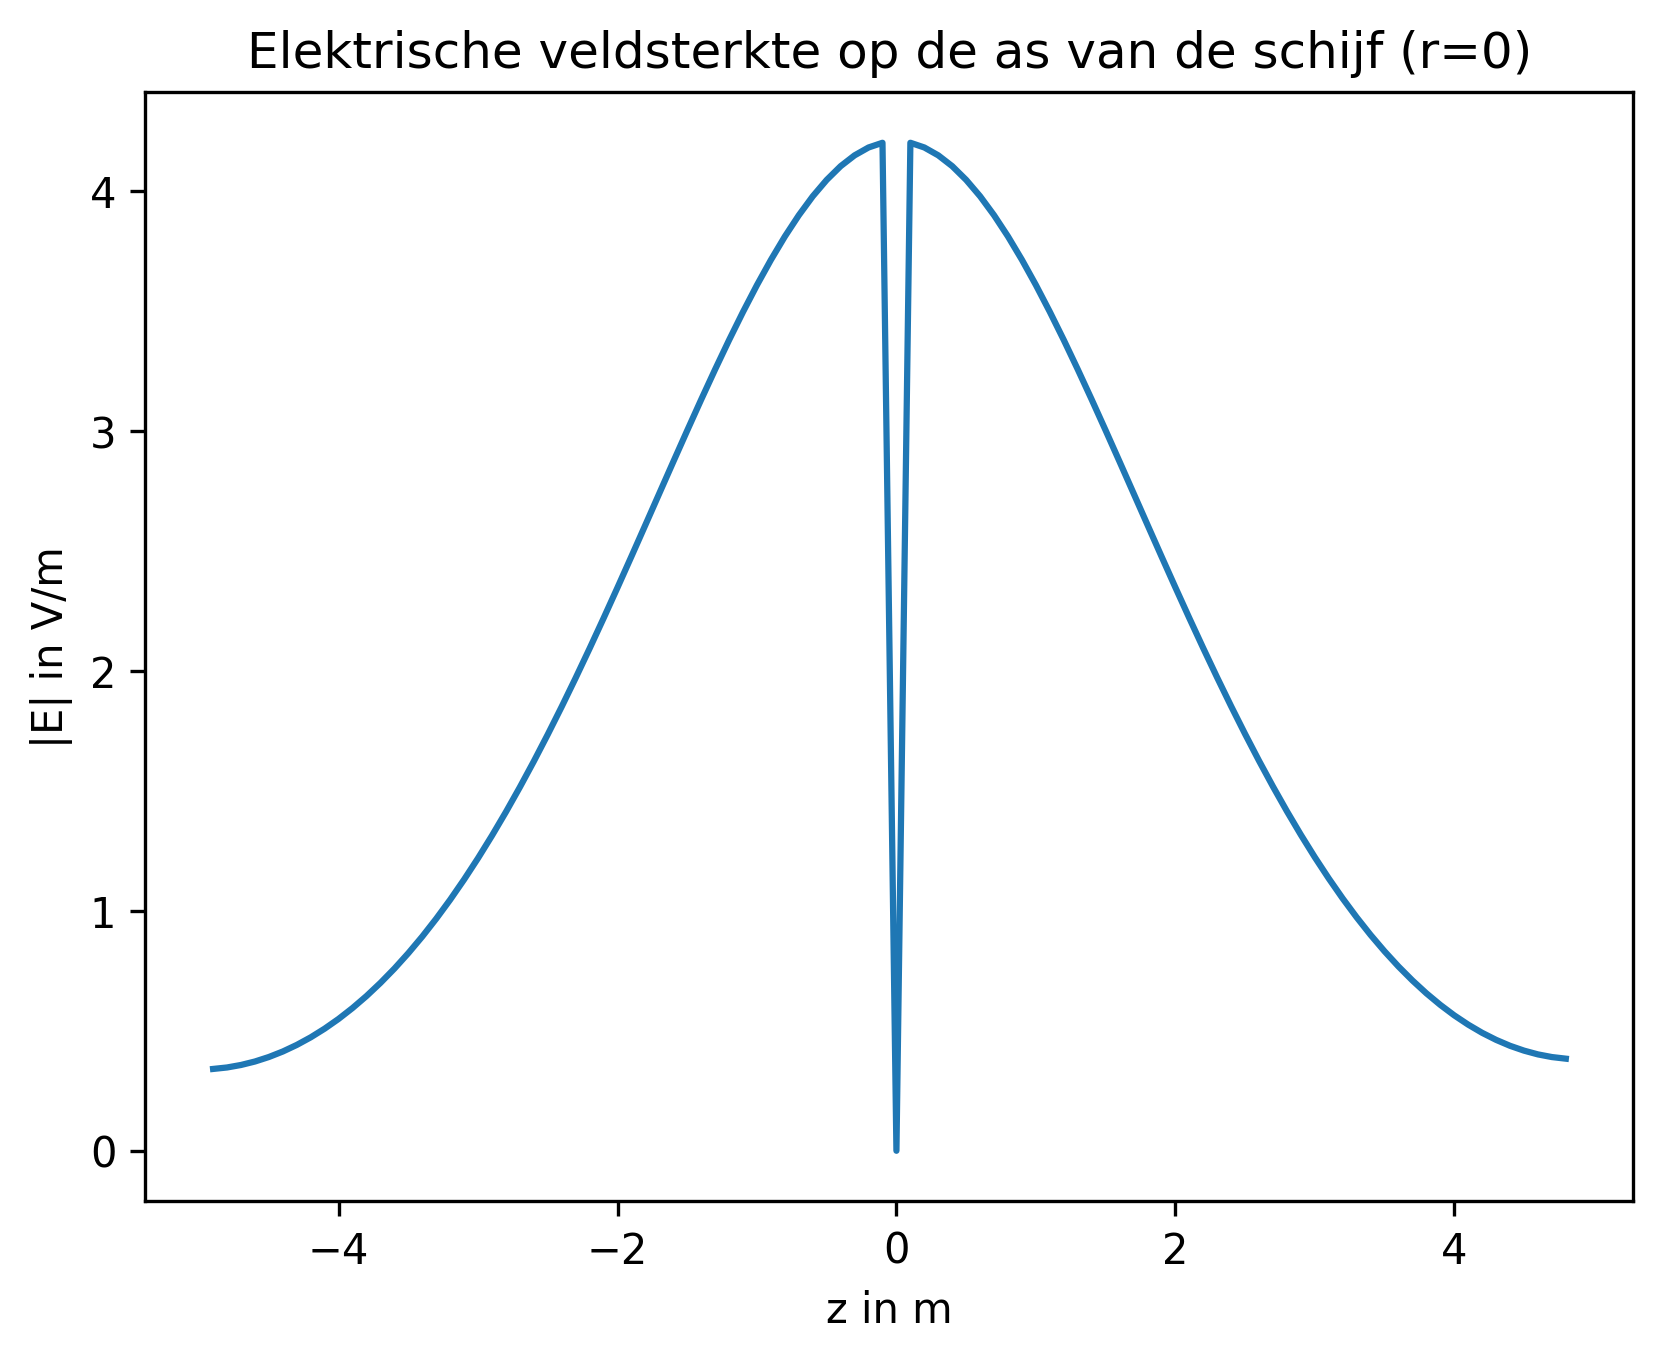

Op afstand 1.000e-01 meter van het midden is de veldsterke 4.202e+00 V/m


In [13]:
#1
index_r0 = np.argmin(np.abs(r_for_E)) # op de as van de schijf is r gelijk aan nul, dus je moet weer de goede index vinden.

E_r0 = normE[:, index_r0] # Nu het elektrische veld bepalen op de as. 

plt.figure(dpi=300)
plt.plot(z_for_E, E_r0, '-') # je gebruikt z_for_E omdat de centered finite-difference method niet de E kan berekenen op het allereerste en allerlaatste gridpunt in de z-dimensie
plt.xlabel('z in m')
plt.ylabel('|E| in V/m')
plt.title('Elektrische veldsterkte op de as van de schijf (r=0)')
plt.show()

#2
index_z0 = np.argmin(np.abs(z_for_E)) # index vinden waar z nul is.

index_z_near = index_z0 + 1 # we nemen het punt er net na. (je kan ook het punt ervoor nemen).

# veldsterkte op de as vlak bij het midden
E_near_z0 = normE[index_z_near, index_r0]
z_near = z_for_E[index_z_near]

print('Op afstand {:.3e} meter van het midden'.format(z_near),'is de veldsterke {:.3e} V/m' .format(E_near_z0))

#### Vraag 3b: De oppervlakte lading in het midden van een geleidende schijf op constant potentiaal

1. Met welke formule kan je de oppervlaktelading benaderen in het midden van de schijf($r=0$, $z=0$)?
2. Print netjes de benadering van de oppervlakte lading in het midden van de schijf.

##### Antwoord 3b
s = e0*Ez

sigma = oppervlakteladingsdichtheid in C/m^2

e0 = de permittiviteit van vacuum in F/m. (8.854e-12)

Ez = elektrische veldsterkte loodrecht op het oppervlak in V/m of N/C

In [14]:
#2
index_r0 = np.argmin(np.abs(r_for_E)) # Deze drie regels hadden we ook al bij 3a
index_z_0 = np.argmin(np.abs(z_for_E))
index_z_near = index_z_0 + 1
Ez_near = Ez[index_z_near, index_r0] #Hier pak je weer het veld dicht bij z=0 en r=0.

sigma = epsilon0 * Ez_near


print("De benadering van de oppervlakteladingsdichtheid in het midden van de schijf is {:.3e}".format(sigma),'C/m^2')

De benadering van de oppervlakteladingsdichtheid in het midden van de schijf is 3.720e-11 C/m^2


#### Vraag 3c: De oppervlaktelading van een geleidende schijf op constant potentiaal

De oppervlakte lading $\sigma(r)$ van een geleidende schijf met straal $R$ is niet uniform verdeeld over de schijf, maar wordt gegeven door (Problems 2.58 and 2.63 Griffiths 5th edition):
$$\sigma(r) = \frac{Q}{2 \pi R \sqrt{R^2 - r^2}}$$

1. Bereken de totale lading op de schijf met behulp van vraag 3a en 3b.
2. Vergelijk de oppervlaktelading in het centrum van de geleidende schijf met dat van een uniform geladen schijf met dezelfde totale lading.
3. Plot de oppervlaktelading van de geleidende schijf met de berekende lading $Q$, tussen $r = 0$ en $R$.
4. Plot in hetzelfde figuur de oppervlaktelading van een uniform geladen schijf met dezelfde lading $Q$.


De totale lading van de schijf is 2.104e-09 C.
Oppervlaktelading uniforme plaat: 7.440627467077898e-11 C/m^2.
Oppervlaktelading niet uniforme plaat: 3.720313733538949e-11 C/m^2.
De verhouding is dus 0.5 * uniforme plaat = niet uniforme plaat. 


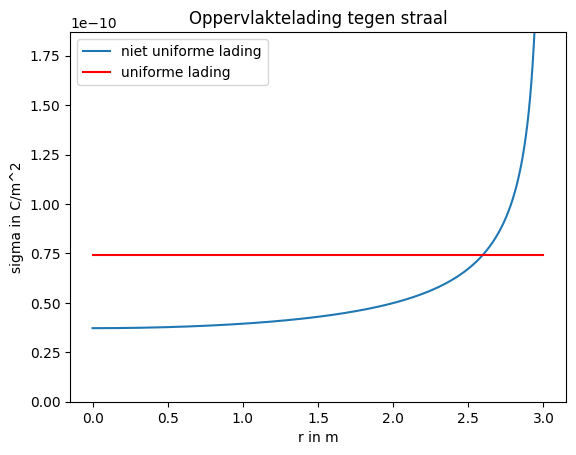

In [15]:
#1.
R = disk_radius # straal van de disc
sigma_r0 = sigma # oppervlakteladingsdichtheid uit vraag 3b

def formule(R,sigma_r0):
    return  2*np.pi*R**2*sigma_r0 # Dit is de gegeven formule omgeschreven met r=0

Q = formule(R,sigma_r0)

print("De totale lading van de schijf is {:.3e}".format(Q),'C.')

#2.
sigma_niet_uniform = Q / (2*np.pi*R**2)
sigma_uniform = Q / (np.pi*R**2) 

print('Oppervlaktelading uniforme plaat: {} C/m^2.'.format(sigma_uniform))
print('Oppervlaktelading niet uniforme plaat: {} C/m^2.'.format(sigma_niet_uniform))
print('De verhouding is dus 0.5 * uniforme plaat = niet uniforme plaat. ')

#3.
eps = 1e-6 * R # je kan niet door nul delen dus net naast de rand.
r_test = np.linspace(0, R-eps, 1000)

def oppvladingnietuniform(R,r_test):
    return Q / (2*np.pi*R*np.sqrt(R**2 - r_test**2))

sigma_niet_uniform = oppvladingnietuniform(R,r_test) 

plt.figure()
plt.plot(r_test, sigma_niet_uniform,label='niet uniforme lading')
plt.plot()
plt.xlabel("r in m")
plt.ylabel('sigma in C/m^2')
plt.title("Oppervlaktelading tegen straal")
plt.ylim(0, np.percentile(sigma_niet_uniform, 98)) #sigma gaat naar oneidig maar dan kan je de grafiek niet goed zien. 

#4.
sigma_uniform = np.ones_like(r_test)*sigma_uniform # hier maak ik een array van lengte r_test met alleen maar 1'en en vervolgens stop ik hem vol met sigma_uniform.
plt.plot(r_test,sigma_uniform,'r',label='uniforme lading')
plt.legend()
plt.show()



#### Vraag 3d: Het edge effect

1. Bepaal het maximum elektrische veld door de geleidende schijf in de simulatie.
2. Bepaal waar in de ruimte dit maximum zich bevindt.
3. Hoeveel hoger is dit maximum dan het elektrische veld in het midden van de schijf?
4. Print met een nette opmaak de waardes die je hier hebt berekend.
5. Leg uit wat de oorzaak van dit lokaal hoge elektrische veld is?


In [16]:
#1.
index_max = np.argmax(normE) # maar nu heb je een 1-D array en je moet z en r weten voor E is maximaal. 
index_z_max, index_r_max = np.unravel_index(index_max, normE.shape) # dat doe je met de unravel index.

E_max = normE[index_z_max, index_r_max]
print("Maximum veldsterkte = {:.3f} V/m.".format(E_max))

#2
r_max = r_for_E[index_r_max]
z_max = z_for_E[index_z_max]
print("Locatie maximum: r = {:.3f} m, z = {:.3f} m.".format(r_max, z_max))

#3
index_r0 = np.argmin(np.abs(r_for_E))
index_z0 = np.argmin(np.abs(z_for_E))
index_z_near = index_z0 + 1

E_center = normE[index_z_near, index_r0]

verhouding = E_max / E_center
print("Het veld in het midden van de schijf is {:.3e} V/m.".format(E_center))
print("E_max is {:.2f} keer groter dan E in het midden van de schijf.".format(verhouding))

Maximum veldsterkte = 11.753 V/m.
Locatie maximum: r = 3.000 m, z = 0.100 m.
Het veld in het midden van de schijf is 4.202e+00 V/m.
E_max is 2.80 keer groter dan E in het midden van de schijf.


##### Antwoord 3d.5

Het hoge elektrische veld aan de rand van de geleidende schijf wordt veroorzaakt door het zogenaamde edge effect. Een geleider heeft overal hetzelfde potentiaal, en het elektrische veld staat loodrecht op het oppervlak. Aan de rand van de schijf stopt het oppervlak abrupt, waardoor de veldlijnen daar sterker moeten buigen.

Doordat de veldlijnen zich aan de rand dichter op elkaar concentreren, hoopt de elektrische lading zich daar meer op dan in het midden. Een grotere oppervlaktelading zorgt direct voor een sterker elektrisch veld vlak buiten de geleider.

Daarom is het elektrische veld het grootst bij de rand van de schijf en niet in het midden.

### 4) Twee geleidende platen op potentiaal $V_1$ and $-V_1$

In de cel hieronder wordt weer op dezelfde manier als in opdracht 3 de laplace vergelijking van deze situatie opgelost.

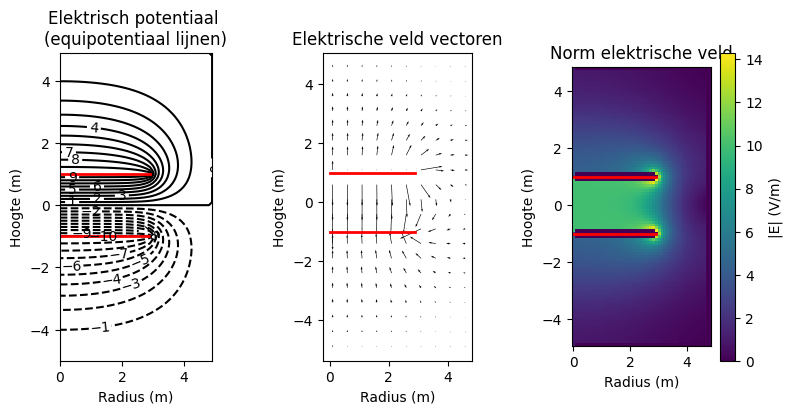

In [17]:
# Run deze cel en pas de cel aan in vraag 4f.
# Voor twee schijven
spacing_between_disks = 2  # (m)
z_pos_disk1 = spacing_between_disks/2  # z-coördinaat van de eerste geleidende schijf (m)
z_pos_disk2 = -spacing_between_disks/2  # z-coördinaat van de tweede geleidende schijf (m)
V1 = 10  # elektrische potentiaal van de eerste geleidende schijf (V)
V2 = -10  # elektrische potentiaal van de tweede geleidende schijf (V)

r, z, r_repmat, V, B, idx_R, idx_z1, idx_z2 = initialize_variables_Laplace(width_domain, disk_radius, height_domain, grid_step, z_pos_disk1, z_pos_disk2, V0, V1, V2)

"""--------------------------------------------------------------------
Veldberekening voor de twee geleidende schijven
"""
solve_Laplace_equation(V, B, r_repmat, grid_step, idx_z1, idx_z2, idx_R, V1, V2, 1e-3)
Er, Ez, normE = compute_E_disk(V, B, grid_step)
r_for_E = r[1:-1]  # de centered finite-difference method kan E niet berekenen op het allereerste en allerlaatste gridpunt in de r-dimensie
z_for_E = z[1:-1]  # de centered finite-difference method kan E niet berekenen op het allereerste en allerlaatste gridpunt in de z-dimensie

""""---------------------------------------------------------
Plot het berekende veld
"""
plot_results_disk(Ez, Er, normE, V, r, z, grid_step, disk_radius, z_pos_disk1, z_pos_disk2)


#### Vraag 4a: Het $z$-component van het numeriek berekende elektrische veld van twee geleidende platen

1. Plot het $z$-component van het numeriek berekende elektrische veld op de as van de schijven.


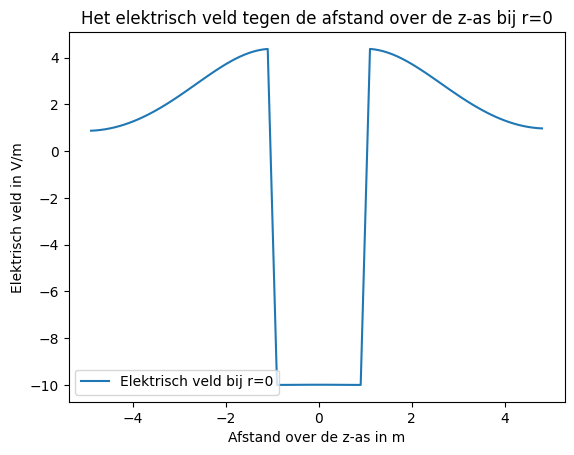

In [18]:
plt.title("Het elektrisch veld tegen de afstand over de z-as bij r=0")
plt.xlabel("Afstand over de z-as in m")
plt.ylabel("Elektrisch veld in V/m")
plt.plot(z_for_E,Ez[:,0], label = "Elektrisch veld bij r=0")
plt.legend()
plt.show()

#### Vraag 4b: Verschillen tussen verschillende configuraties

1. Gegeven het potentiaal tussen twee geleidende platen, wat is het theoretische elektrische veld in elke regio? Laat dit zien met een afleiding en een schets die de verschillende regio's aangeeft.
2. Beschrijf het numeriek berekende elektrische veld op de as van de schijven, komt dit overeen met het theoretische elektrische veld?
3. Vergelijk het numeriek berekende elektrische veld tussen de twee schijven ($r=0$ en $z=0$) met dat van een enkele geleidende schijf op hetzelfde potentiaal(vraag 3a), welk voordeel heeft deze configuratie?

##### Antwoorden 4b

1. De drie regio's zijn boven de bovenste plaat, tussen de twee platen in en onder de onderste plaat. Tussen de platen in is het theoretische elektrische veld gegeven door (V1-V2)/s, waarin s de onderliggende afstand is. Het elektrische veld is daar dus 10 V/m. Boven en onder de schijven hangt de sterkte van het elektrisch veld af van de afstand tot de plaat. Als de afstand s tot de plaat naar oneindig stijgt, daalt de waarde van het elektrische veld naar 0.
![Schets](figures/Schets_opdracht_4b.jpg)

2. Het numeriek berekende elektrische veld bedraagt -10V/m, precies vanaf de onderkant van de bovenste plaat (z=1m) tot de bovenkant van de onderste plaat (z=-1m). De waarde komt overeen, alleen het minteken is onverwacht. Hiervoor kan gecompenseerd worden door V1 en V2 andersom te kiezen.
3. Het voordeel van twee geleidende schijven met een potentiaalverschil is dat het gebied waarin het elektrische veld 10V/m is, veel groter is. Bovendien is dit veld constand qua richting en grootte; met een enkele schijf kan dat niet bereikt worden. Het elektrisch veld boven een enkele schijf neemt namelijk meteen af als de afstand tot de schijf groter wordt. Het veld loopt ook 'schuin', het wijst alleen loodrecht omhoog bij r = 0.

#### Vraag 4c: De capaciteit tussen twee geleidende platen

1. Bepaal de verwachte oppervlaktelading op de binnenzijde van een van de schijven.
2. Bepaal de verwachte totale lading op beide schijven.
3. Bepaal de capaciteit van deze situatie.
4. Print alle bepaalde waardes op een nette en overzichtelijke manier.

In [19]:
#1.
sigma1 = epsilon0*Ez[idx_z1][29] #Aan de onderkant van de bovenste schijf
sigma2 = epsilon0*Ez[idx_z2][0] #Aan de bovenkant van de onderste schijf
sigma3 = epsilon0*Ez[idx_z1][0] #Aan de bovenkant van de bovenste schijf
sigma4 = epsilon0*Ez[idx_z2][29] #Aan de onderkant van de onderste schijf

oppLading1 = 2*np.pi*disk_radius**2*sigma1
oppLading2 = 2*np.pi*disk_radius**2*sigma2
oppLading3 = 2*np.pi*disk_radius**2*sigma3
oppLading4 = 2*np.pi*disk_radius**2*sigma4

print("De lading op het oppervlakte aan de binnenkant van een schijf is: {:.3e} C".format(oppLading1))

#2.
totLading1 = oppLading1+oppLading3
totLading2 = oppLading2+oppLading4
print("De totale lading op schijf 1 en schijf 2 respectievelijk is: {:.3e} C en {:.3e} C".format(totLading1,totLading2))

#3.
def Capaciteit(A,d):
    return epsilon0*A/d
print("De capaciteit tussen beide schijven is: {:.3e} F".format(Capaciteit(schijfOpp, spacing_between_disks)))

De lading op het oppervlakte aan de binnenkant van een schijf is: 2.412e-09 C
De totale lading op schijf 1 en schijf 2 respectievelijk is: 4.604e-09 C en -9.002e-09 C
De capaciteit tussen beide schijven is: 1.252e-10 F


De totale lading van beide schijven is berekend door de oppervlaktelading van alle schijfoppervlakken op te tellen. De onderste schijf is negatiever geladen dan de bovenste schijf positief, omdat de index daar waarschijnlijk dichter bij de schijf zit.

#### Vraag 4d: Theoretische oppervlaktelading

1. Is de oppervlaktelading aan de buitenkant van de schijven gelijk aan nul, beargumenteer waarom wel of niet.
2. Wat is het elektrische veld nabij het oppervlak van een geleider?

##### Antwoorden 4d

1. Nee, maar wel kleiner dan de lading aan de binnenkant van de platen. De lading wordt namelijk aangetrokken door de tegenovergestelde lading aan de andere schijf, maar ondertussen stoot de lading in een schijf dezelfde lading af, weg van de andere schijf. Daardoor is er ook nog lading aanwezig aan de andere kant van de schijf. Dit is ook te zien aan het elektrische veld, dat aan de buitenkant kleiner, maar niet direct 0 is.
2. Het elektrische veld vlakbij het oppervlak is gelijk aan sigma/epsilon0.

#### Vraag 4e: Numeriek berekende ladingsdichtheid

1. Welke waarde heeft het $z$-component van het elektrische veld, op de as van de schijf net onder de onderste schijf.
2. Wat is volgens de formule uit vraag 4d 2 de ladingsdichtheid aan de onderkant van de onderste geleidende plaat.
3. Welke waarde heeft het $z$-component van het elektrische veld, op de as van de schijf net boven de onderste schijf.
4. Wat is volgens de formule uit vraag 4d 2 de ladingsdichtheid aan de bovenkant van de onderste geleidende plaat.
5. Print de bepaalde waardes op een nette en overzichtelijke manier.

In [20]:
#1.
Ez_max = np.max(Ez[:,0]) #Vlak onder de onderste schijf is het elektrische veld maximaal
print("De waarde van de z-component van het elektrische veld vlak onder de onderste schijf is: {:.3e} V/m".format(Ez_max))

#2. 
sigma_onder_onder = Ez_max*epsilon0
print("De waarde van sigma vlak onder de onderste schijf is: {:.3e} C/m^2".format(sigma_onder_onder))

#3.
Ez_min = np.min(Ez[:,0]) #Vlak boven de onderste schijf is het elektrische veld minimaal (niet in grootte, maar wel met minteken)
print("De waarde van de z-component van het elektrische veld vlak boven de onderste schijf is: {:.3e} V/m".format(Ez_min))

#4.
sigma_boven_onder = Ez_min*epsilon0
print("De waarde van sigma vlak boven de onderste schijf is: {:.3e} C/m^2".format(sigma_boven_onder))

De waarde van de z-component van het elektrische veld vlak onder de onderste schijf is: 4.378e+00 V/m
De waarde van sigma vlak onder de onderste schijf is: 3.876e-11 C/m^2
De waarde van de z-component van het elektrische veld vlak boven de onderste schijf is: -1.000e+01 V/m
De waarde van sigma vlak boven de onderste schijf is: -8.858e-11 C/m^2


#### Vraag 4f: Conclusies over de ladingsdichtheid op de twee schijven

1. Wat kan je uit vraag 4d en e concluderen over de daadwerkelijke lading op een schijf in tegenstelling tot de berekende lading in vraag 4c?
2. Wat is de invloed hiervan op de capaciteit berekend in vraag 4c?
3. Run de cel net onder het kopje vraag 4 opnieuw, maar dan met een kleinere afstand tussen de schijven, wat verandert er?

##### Antwoorden 4f

1. De berekende lading van de onderste schijf in vraag 4c is: -9.00e-9 C. Als we de ladingsdichtheid van vraag 4e van de onderkant van de onderste schijf met het oppervlak vermenigvuldigen, krijgen we een waarde van 1.096e-9 C. Dit is iets lager, zelfs als we de lading van dezelfde schijf, maar dan aan de bovenkant, -2.505e-9 C, hierbij optellen. Dit zou echter wel ongeveer overeenkomen met de lading op de bovenste schijf. Waarschijnlijk komt dit doordat de index bij de ene schijf iest dichter is gekozen bij de schijf. Concluderend kunnen we zeggen dat de berekende lading iets hoger uitvalt dan de daadwerkelijke lading.

2. Dit heeft geen effect op de waarde van de capacitor, want deze hangt alleen af van de afstand tussen de platen en de oppervlakte van de platen.

3. De afstand tussen de platen is gehalveerd van 2 naar 1 meter. Het elektrische veld tussen de platen wordt groter, terwijl het veld buiten de platen zo goed als gelijk blijft. De capaciteit verdubbelt. De waardes van sigma blijven gelijk aan de buitenkant van de platen, terwijl ze aan de binnenkant van de platen groter worden met een factor twee.

### 5) Voorbereidende opdracht voor de fysieke DEF ontwerpopdracht

In deze vraag zullen we ingaan op benodigde voorkennis voor de fysieke ontwerpopdracht "Maak een sensor met condensatoren". De formules die je in deze opdracht opstelt, heb je nodig gedurende de fysieke ontwerpopdracht.

In deze vraag zullen we kijken naar de ideale vlakke plaat condensator. Als de afstand tussen de platen veel kleiner is dan de grootte van de platen dan wordt de aanname gemaakt dat het veld tussen de platen constant is. Deze aanname zal niet helemaal overeenkomen met de werkelijkheid, zoals je in deze opdracht en de fysieke DEF ontwerpopdracht achter zal komen.

#### Vraag 5a: Functies voor de capaciteit van enkele opdrachten

1. Vind de formule voor de capaciteit van een vlakke plaat condensator en een cilinder condensator, onder de aanname dat de afstand tussen de platen veel kleiner is dan het oppervlakte van de condensator (vlakke plaat aanname).
2. Schrijf een python functie die de relevante parameters als input neemt en de capaciteit van een vlakke plaat condensator als output heeft.
3. Vind de formule voor de capaciteit van een cilinder condensator onder de aanname dat de afstand tussen de binnen en buiten wand klein is.
4. Schrijf een python functie die de relevante parameters als input neemt en de capaciteit van een cilinder condensator als output heeft.

In [21]:
def vlakkeplaat(epsilon, A, d):
    C = epsilon * A/d
    return C

def cilinder(epsilon, a, b, L):
    C = epsilon * 2*np.pi*a*L/(b-a)
    return C

#### Vraag 5b: Capaciteit van enkele simpele condensatoren

Gebruik in deze opdracht de functie die je bij vraag 5.1 geschreven hebt.
Hieronder staan een aantal condensatoren waarvoor jullie de capaciteit gaan berekenen. Print de capaciteit van elke condensator op een nette en overzichtelijke manier.
1. Bereken de capaciteit van een condensator gemaakt van twee vierkante plaatjes van 10 bij 10 cm met een plaatafstand van 1 mm en lucht als medium?
2. Bereken de capaciteit van een cilinder condensator met een binnendiameter van 9 mm en een buitendiameter van 10 mm met een lengte van 10 cm en lucht als medium?
3. Bereken de capaciteit van de condensatoren als de afstand tussen de platen verdubbeld
4. Bereken de capaciteit van de condensatoren uit 1 en 2 hierboven beschreven als ze gevuld zijn met water.
5. Bereken de capaciteit van de condensatoren uit 1 en 2 hierboven als de holte gevuld is met PVC.


In [22]:
#1.
A1 = 0.10 * 0.10
d1 = 1e-3
epsilon_lucht = epsilon0 * 1
C1 = vlakkeplaat(epsilon_lucht, A1, d1)
print("1. C is {:.3e} F.".format(C1))

#2.
a = 9e-3 / 2
b = 10e-3 / 2
L = 0.10
C2 = cilinder(a, b, L, epsilon_lucht)
print("2. C is {:.3e} F.".format(C2))

# 3. Afstand verdubbeld
C1_dubbel = C1/2

d2 = b - a
d2_dubbel = 2 * d2
C2_dubbel = epsilon_lucht * (2*np.pi*a*L) / d2_dubbel
print("3. C met 2*d vlakke plaat {:.3e} F en C met 2*d cilinder is {:.3e} F.".format(C1_dubbel,C2_dubbel))

#4. 
epsilon_water = epsilon0 * 80 # opgezocht internet.
C1_water = vlakkeplaat(epsilon_water, A1, d1)
C2_water = cilinder(a, b, L, epsilon_water)
print("4. C vlakke plaat met water is {:.3e} F en C cilinder met water is {:.3e} F.".format(C1_water,C2_water))

# 5.
epsilon_pvc = epsilon0 * 3 # opgezocht internet.
C1_pvc = vlakkeplaat(epsilon_pvc, A1, d1)
C2_pvc = cilinder(a, b, L, epsilon_pvc)
print("5. C vlakke plaat met PVC is {:.3e} F en C cilinder met PVC is {:.3e} F.".format(C1_pvc,C2_pvc))

1. C is 8.854e-11 F.
2. C is 1.318e-14 F.
3. C met 2*d vlakke plaat 4.427e-11 F en C met 2*d cilinder is 2.503e-11 F.
4. C vlakke plaat met water is 7.083e-09 F en C cilinder met water is 1.054e-12 F.
5. C vlakke plaat met PVC is 2.656e-10 F en C cilinder met PVC is 3.953e-14 F.


#### Vraag 5c: Condensatoren uit het dagelijkse leven

Gebruik in deze opdracht de functie die je bij vraag 5.1 geschreven hebt.
Hieronder is een foto te zien van condensatoren die in het dagelijkse leven gebruikt wordt.
Print de capaciteiten in deze vraag op een nette en overzichtelijke manier.
1. In figuur 5.1 is een condensator te zien van 1 $\micro$F, stel deze condensator kan geapproximeerd worden als een cilinder condensator met binnendiameter 5 mm en een buitendiameter van 6 mm. Bereken wat de lengte van de condensator dan zou zijn.
Stel dat we een vierkante plaat condensator hebben van 1 $\micro$F.
2. Bereken hoe lang de vlakke plaat condensator moet zijn als er 0.5 mm tussen de platen zit en de platen 6 mm breed zijn.

![figure 5.1](figures/Condensator_1_uF.jpg)

##### Figure: 5.1 Een 1 microfarad condensator.

In [23]:
C = 1e-6 #gegeven target

#1.
a = 5e-3 / 2
b = 6e-3 / 2
d = b - a
L = C * d / (2*np.pi*epsilon0*a)
print("1. De benodigde lengte L is {:.3e} m.".format(L))

#2.
d = 0.5e-3
breed = 6e-3
L = C * d / (epsilon0 * breed)
print("2. De benodigde lengte L is {:.3e} m.".format(L))

1. De benodigde lengte L is 3.595e+03 m.
2. De benodigde lengte L is 9.412e+03 m.


#### Vraag 5d: Hoge capaciteit condensatoren

1. Beargumenteer of je antwoorden uit vraag 5c realistisch zijn.
2. Bekijk je formule uit vraag 5a en bedenk hoe ze dit binnen in de condensator opgelost hebben.

##### Antwoorden 5d

De antwoorden uit vraag 5c zijn niet echt realistisch. Het is vrij onwaarschijnlijk dat er kilometers aan cilinder in de condensator zitten. Uit de formule van 5a blijkt dat je dit op twee manieren kan oplossen: 1. Het gebruiken van een ander materiaal tussen de platen dan lucht, zodat er een hogere permittiviteit is en de benodigde lengte minder is. 2. De onderlinge afstand d tussen de platen kan worden verlaagd. Ook hierdoor wordt de benodigde lengte minder. Ze hebben dit probleem dus opgelost door de permittivieteit te verhogen en de onderlinge afstand te verlagen.

#### Vraag 5e: Condensator in een achtbaan

Gebruik in deze opdracht de functie die je bij vraag 5.1 geschreven hebt.

Met het vak inleidend practicum zijn jullie naar Drievliet gegaan om daar metingen aan de attracties te doen. In Drievliet staat de achtbaan Formule X, deze achtbaan heeft een topsnelheid van 70 $\frac{\text{km}}{\text{h}}$ en bevat een treintje met plek voor 6 mensen. Deze snelheid bereikt de achtbaan door heel snel een karretje weg te schieten, dit wordt gedaan door de treintjes met een lineaire inductie motor te versnellen. Om de impact hiervan op het stroomnet te beperken gebruiken zij een condensator om de energie op te slaan en dan in een keer af te staan aan het treintje. In deze opdracht gaan we kijken wat de afmetingen zouden moeten zijn als ze vlakke plaat condensatoren zouden gebruiken.

De energie die opgeslagen is in een condensator kan berekend worden met de onderstaande formule.

$E = \frac{1}{2} CV^2$
Hierin is $E$ de totaal opgeslagen energie $C$ de capaciteit en $V$ het voltage waarop de condensator opereert, in dit geval $10$ $kV$.
1. Schat de massa van een treintje dat afgeschoten wordt.
2. Bereken de totale energie van het treintje na het afschieten.
3. Bereken de totale capaciteit van de condensator.
4. Bereken het oppervlakte van een vlakke plaat condensator die deze capaciteit heeft als die gevuld is met water en de platen 1 mm van elkaar afstaan.
5. Print alle berekende waardes op een nette en overzichtelijke manier.
6. Is dit realistisch, bedenk een manier hoe dit toch kan in een relatief klein volume.


In [24]:
#1.
m = 750 # schatting in kg

#2.
v = 70              # km/h gegeven
v = v / 3.6         # in m/s
E = 0.5 * m * v**2

#3.
V = 10000
C = 2 * E / V**2

#4.
epsilon_water = epsilon0 * 80
d = 1e-3
A = C * d / epsilon_water

# 5. Print overzicht
print("m = {:.0f} kg".format(m))
print("v = {:.2f} m/s".format(v))
print("E = {:.3e} J".format(E))
print("C = {:.3e} F".format(C))
print("A = {:.3e} m^2".format(A))

m = 750 kg
v = 19.44 m/s
E = 1.418e+05 J
C = 2.836e-03 F
A = 4.003e+03 m^2


##### Antwoorden 5e

6. Dit is niet realisctisch, je krijgt een veel te groot oppervlakte en dat past nooit onder die achtbaan. Dit lossen ze op door poreuze materialen te gebruiken waardoor het inwendige oppervlak erg groot is. Ook is de afstand tussen de ladingen heel klein.

#### Vraag 5f: Veranderende capaciteit

Gebruik in deze opdracht de functie die je bij vraag 5.1 geschreven hebt.

1. Bereken en plot de capaciteit van een vlakke plaat condensator van $10$ bij $10$ $cm$ waarbij de afstand tussen de platen lineair toeneemt van $0.5$ $mm$ tot $5$ $mm$.
2. Bereken en plot de capaciteit van een cilinder condensator met een binnendiameter van 9 mm en een buitendiameter van 10 mm en 10 cm lang, waarbij de binnencilinder er langzaam in 10 seconde uitgetrokken wordt.

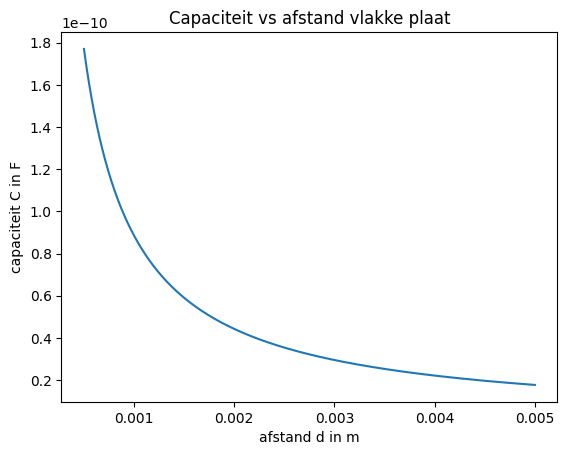

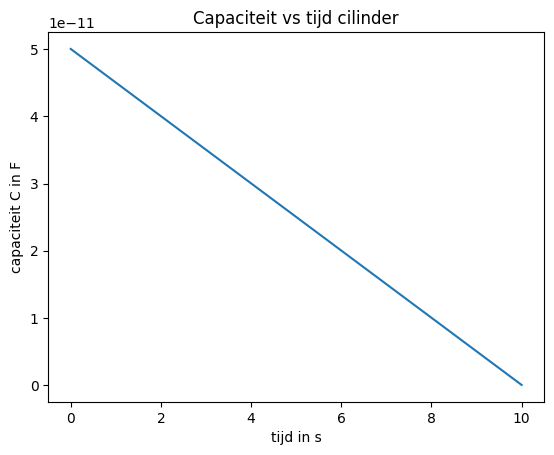

In [25]:
#1. 
A = 0.10 * 0.10
d = np.linspace(0.5e-3, 5e-3, 1000)

C = vlakkeplaat(epsilon0, A, d)

plt.figure()
plt.plot(d, C)
plt.xlabel("afstand d in m")
plt.ylabel("capaciteit C in F")
plt.title("Capaciteit vs afstand vlakke plaat")
plt.show()

#2.
a = 9e-3 / 2
b = 10e-3 / 2
t = np.linspace(0, 10, 1000)
L = 0.10 * (1 - t/10)

C = cilinder(epsilon0, a, b, L)

plt.figure()
plt.plot(t, C)
plt.xlabel("tijd in s")
plt.ylabel("capaciteit C in F")
plt.title("Capaciteit vs tijd cilinder")
plt.show()


## Stop hier met werken tot na de fysieke ontwerpopdracht in week 3.

### 6) Reflectie opdracht voor na de fysieke ontwerpopdracht


Als het goed is, heeft ieder teamlid van deze simulatie-opdracht een andere opstelling ontworpen hebben tijdens de fysieke ontwerpopdracht. Kies in goed overleg voor deze opdracht een van jullie twee ontwerpen.

Voeg hieronder eerst een foto in van je opstelling die je gekozen hebt.

Jullie gaan in deze opdracht het verschil tussen jullie voorspelde verband en jullie uiteindelijke verkregen kalibratie grafiek proberen te verklaren. Er zijn hiervoor drie mogelijke paden die jullie kunnen kiezen om te onderzoeken, Kies deel a, b of c en werk die volledig uit voor jullie ontwerp. Let op je hoeft er maar een uit te werken.

Verander de tekst hieronder zodat deze naar jouw foto verwijst. Zorg dat de foto in de map figures staat!
![figure 5.1](figures/opstelling.jpeg)

#### Vraag 6a: Dunne laag niet meegerekende diëlektricum
Deze vraag is goed om te kiezen als je in je ontwerp een kleine laag extra materiaal hebt en deze tijdens de ontwerpopdracht niet hebben meegenomen in je theoretisch kalibratie grafiek.

1. Maak een nieuwe schets van je opstelling waarbij je de dikte van het extra diëlektricum meeneemt.
2. Leid de analytische oplossing af van de capaciteit van de hierboven getekende situatie.
3. Programmeer de analytische oplossing in python.
4. Maak hierna een plot van het kalibratiegrafiek, oude en nieuwe analytische oplossing in een grafiek.
5. Beschrijf en verklaar de verschillen tussen de grafieken.


##### Antwoorden 6a

![figure 5.2](figures/nieuweschets.jpeg)

Er zit dus tussen de kartonnetjes een extra laagje lucht. Dat komt omdat we het kartonnenplaatje vast moesten maken aan het metalen plaatje en daardoor er wat ductape tussen de twee kartonnetjes komt. Dit zorgt ervoor dat de kartonnen plaatjes niet perfect op elkaar liggen en een een stukje lucht met een dikte van 2 ducttapejes tussen zit. Twee omdat je aan beide kanten een stukje karton hebt en die op elkaar lagen.

De analytische oplossing volgt uit het feit dat er tussen de metalen platen niet één homogeen diëlektricum zit, maar twee lagen achter elkaar: karton en een extra luchtlaag door de ducttape. Deze twee lagen werken als diëlektrica in serie. Daardoor wordt de effectieve afstand tussen de platen groter dan alleen de dikte van de twee kartonnetjes.
Omdat de capaciteit omgekeerd evenredig is met de effectieve afstand tussen de platen, zorgt de extra luchtlaag ervoor dat de capaciteit kleiner wordt dan in het oorspronkelijke model waarin deze laag niet was meegenomen. Het verband tussen capaciteit en oppervlakte blijft verder hetzelfde

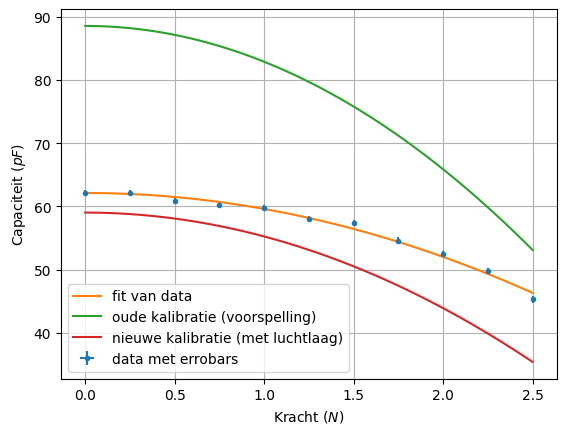

In [26]:

epsillon_karton = 3*epsilon0

# code voor de voorspellende grafiek zonder het extra dielektrium meegenomen
A = 0.01*np.linspace(1,0.6,100)
d = 3e-3

C = vlakkeplaat(epsillon_karton,A,d)

indx_max = np.argmax(C)
C_max = C[indx_max] # voor de fit zodat je b weet 

indx_min = np.argmin(C)
C_min = C[indx_min]

F = np.linspace(0,2.5,100)
Fmax = 2.5

C_oud = C_max - (C_max-C_min)*(F/Fmax)**2

# code voor de voorspellende grafiek met het meenemn van het extra dielktricum

d_k = 3e-3
d_lucht = 0.5e-3 # twee keer dikte kartonnetje
eps_r_karton = 3
eps_r_lucht = 1

def schaalfactor(d_k, eps_r_k, d_lucht, eps_r_lucht):
    return (d_k/eps_r_k) / ((d_k/eps_r_k) + (d_lucht/eps_r_lucht))

s = schaalfactor(d_k, eps_r_karton, d_lucht, eps_r_lucht)

C_nieuw = s*C_oud

# data met fit

Arduino = np.array([62.1,60.9,59.7,57.4,52.5,45.3,62.1,60.2,58.0,54.6,49.8])
Veerunster = np.array([0,0.5,1.0,1.5,2.0,2.5,0.25,0.75,1.25,1.75,2.25])

def func(x,a,b):
    return a*x**2+b

val, cov = curve_fit(func,Veerunster,Arduino)
a_fit = val[0]
b_fit = val[1]

xtest = np.linspace(0,2.5,200)
yfit = func(xtest,a_fit,b_fit)

plt.figure()
plt.errorbar(Veerunster,Arduino,xerr=0.01,yerr=0.5,fmt='.',label='data met errobars')
plt.plot(xtest,yfit,label='fit van data')
plt.plot(F,C_oud*1e12,label='oude kalibratie (voorspelling)')
plt.plot(F,C_nieuw*1e12,label='nieuwe kalibratie (met luchtlaag)')
plt.xlabel('Kracht ($N$)')
plt.ylabel('Capaciteit ($pF$)')
plt.legend()
plt.grid()
plt.show()

##### Antwoorden 6a

Het verschil tussen de twee grafieken komt neer op een verschuiving naar beneden over de capaciteitsas. Dit is volkomen logisch, omdat er bij de nieuwe fit een kleine luchtlaag tussen de twee platen is toegevoegd. Dit extra laagje zorgt voor een grotere d; de capaciteit is omgekeerd evenredig met d, dus een grotere d zorgt voor een kleinere C, wat evident is uit de grafiek. Verder is de nieuwe fit iets minder stijl, dat is te verklaren doordat de wrijving in de data lager was dan in de nieuwe theoretische fit. Hierdoor is de hoeveelheid kracht benodigd om het plaatje een bepaalde afstand te verschuiven groter bij de nieuwe fit.

#### Vraag 6b1: Lading op een condensator met het edge effect meegenomen

In deze opdracht gaan we verder in op het Edge effect en de invloed daarvan op de praktische capaciteit. Deze opdracht bouwt voort op de vraag 4.3.
Jullie hebben tijdens de ontwerpopdracht vierkante platen gebruikt in tegenstelling tot de ronde platen waarvoor de factoren in figure[label] zijn afgeleid. Er is onderzoek gedaan naar de factoren waarmee de praktische capaciteit vergeleken met de daadwerkelijke capaciteit verschilt dat onderzoek vind je hier: https://ieeexplore.ieee.org/stamp/stamp.jsp?tp=&arnumber=311759. Zoek in het onderzoek tabel 1 en formules 22 en 36 op.

1. Vergelijk de factor waarmee de schijf(disk) condensator verschilt met die van de vierkante plaat, kunnen we de vierkante plaat factor benaderen met de factor voor een disk condensator? Vergelijk het procentuele verschil tussen de factoren van de circulaire en vierkante platen, met de onzekerheden die in de meting zitten.



##### Antwoord 6b1

*Vergelijk hier de factoren tussen de circulaire en vierkante vlakke plaat condensatoren.*

#### Vraag 6b2: Capaciteit van een condensator met het edge effect meegenomen

Vanaf hier nemen we aan dat factor van de circulaire platen ongeveer gelijk is aan de factor voor vierkante platen. De factor die de capaciteit van de vlakke plaat approximatie linkt aan de werkelijke capaciteit noemen we vanaf nu de idealiteitsfactor.

1. Bereken de daadwerkelijke theoretische capaciteit van de condensator uit de sanity check 3 van de fysieke ontwerpopdracht en print deze op een nette manier.
2. Vergelijk dit met de daadwerkelijke theoretische capaciteit met de capaciteit die je op de dag zelf hebt gemeten.

Vanaf hier gaan we verder met jullie sensor van de ontwerpopdracht "Maak een sensor met condensatoren":

3. Reken je theoretische kalibratie grafiek om met de idealiteitsfactor.
4. Vergelijk je nieuwe theoretische kalibratiegrafiek van je praktische kalibratiegrafiek van de dag zelf.

In [27]:
# Schrijf hier jouw code die de vlakke plaat capaciteit omschrijft naar de werkelijke capaciteit

# def C_niet_ideaal(#relevante parameters):
    # Jouw berekeningen


##### Antwoorden 6b2

*Doe in deze markdown cel je vergelijkingen voor de sanity check condensator en je kalibratiegrafiek.*

#### Vraag 6c: Niet linear diëlektricum optie 1

Niet alle materialen zijn een lineair diëlektricum. Een aantal van de materialen die sterk niet lineair gedrag vertonen zijn: sponzen, foam & rubber. Als je in je opdracht een materiaal gebruikt heb waarvan je verwacht dat het verband sterk niet lineair is kan dit een hele goede opdracht zijn.
| Materiaal |$\chi_2$   |
| :-------------|:-------------|
| Spons|  |

Als jouw materiaal hier niet tussen staat dan kan je zelf op zoek naar een waarde van $\chi_2$ in de literatuur.

#### Vraag 6c1

1. Leidt het D veld van de condensator af uit de wet van Gauss.
2. Vindt een analytische uitdrukking voor het elektrisch veld in termen van het D veld.

##### Antwoorden 6c 1

*Antwoord vraag 6c 1.*

#### Vraag 6c2

1. Programmeer je oplossingen voor het D en E veld in python, gebruik het D veld uit je fysieke ontwerpopdracht.

Als je het elektrische veld van een vierkante vlakke plaat condensator weet kan je de capaciteit berekenen met de onderstaande formule:
$C = \frac{A
E_z \epsilon_0}{\Delta V}$

2. Plot de capaciteit van het niet lineaire diëlektricum, het theoretische kalibratiegrafiek en de uiteindelijke kalibratiegrafiek van de fysieke ontwerpopdracht.
3. Verklaar verschillen tussen de grafieken.

In [28]:
 # Pas deze code aan zodat jouw opstelling doorgerekend wordt
def E_condensator(x1, x2, D):
    return None

#### Vraag 7

Hoeveel van de afwijking tussen je metingen en je oorspronkelijke voorspelde kalibratiegrafiek wordt verklaard door wat je bij vraag 6 hebt uitgerekend? Kan je een (aantal) elektrisch veld en capaciteit gerelateerde reden(en) verzinnen wat de rest van de afwijking tussen meting en voorspelde kalibratiegrafiek kan verklaren?

##### Antwoorden 7
Het verschil tussen de oorspronkelijke kalibratiegrafiek en de metingen is aanzienlijk groter dan het verschil tussen de nieuwe kalibratiegrafiek, waarin een extra luchtlaag is meegenomen, en de metingen. Het is opvallend dat de nieuwe kalibratiegrafiek onder de metingen ligt, terwijl de oude kalibratiegrafiek boven de metingen ligt. Dit toont aan dat het toevoegen van de extra luchtlaag wel een deel van de verklaring van het verschil tussen de grafieken is, maar niet de enige reden. Dan zou de nieuwe kalibratiegrafiek namelijk vrijwel exact overeenkomen met de metingen. Verder lijkt er een overige systematische fout aanwezig te zijn; deze is waarschijnlijk veroorzaakt door een foutieve waarde van epsilon_r. De waarde van epsilon_r van karton is verschillend per soort karton en de determinatie van de juiste soort karton is gecompliceerd. Verder kan er een onnauwkeurigheid aanwezig zijn geweest in het overlappende oppervlak of de dikte van het karton. Vooral de dikte van het karton ligt erg nauw samen met de capaciteit, waardoor een kleine meetafwijking hierin voor een vrij grote systematische fout zou zorgen.